<span style="font-size:30px;">       IMPLEMANTAION 1      </SPN>

**<span style="font-size:20px;"> Classification </SPN>**

**CNN**

In [10]:
!pip install tensorflow

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, mean_absolute_error,  mean_squared_error, r2_score, mean_absolute_percentage_error

In [5]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Potato/Train",
    shuffle=True,
    image_size=(256, 256),
    batch_size=32
   
)
class_names = train_ds.class_names
print("Classes identified:", class_names)


val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Potato/Valid",
    image_size=(256, 256),
    batch_size=32
)
class_names = train_ds.class_names
print("Classes identified:", class_names)


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Potato/Test",
    shuffle=False,
    image_size=(256, 256),
    batch_size=32
)
class_names = train_ds.class_names
print("Classes identified:", class_names)

Found 900 files belonging to 3 classes.
Classes identified: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Found 300 files belonging to 3 classes.
Classes identified: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Found 300 files belonging to 3 classes.
Classes identified: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


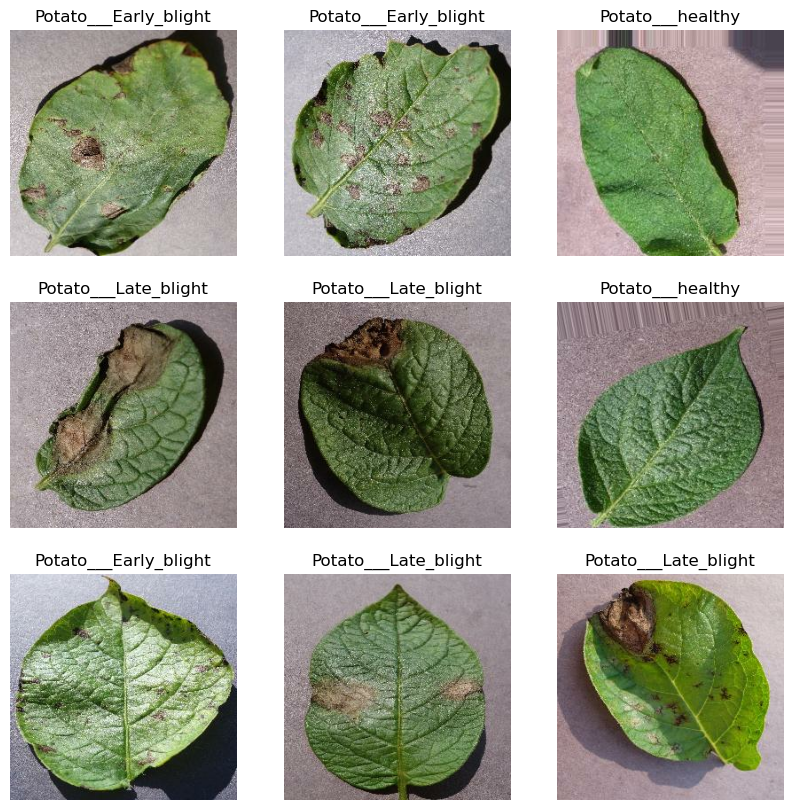

In [12]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
    
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

CNN MODEL ARCHITECTURE 

In [13]:
n_classes = 3

model = models.Sequential([
   
    layers.InputLayer(input_shape=(256, 256, 3)),
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │       3,686,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,742,979 (14.28 MB)

 Trainable params: 3,742,979 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

MODEL COMPILING 

In [14]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [15]:
EPOCHS = 10

history = model.fit(
    train_ds,              
    epochs=EPOCHS,
    batch_size=32,
    verbose=1,
    validation_data=val_ds 
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4422 - loss: 1.0800 - val_accuracy: 0.4100 - val_loss: 1.3480
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7267 - loss: 0.5995 - val_accuracy: 0.7133 - val_loss: 0.5221
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8767 - loss: 0.2709 - val_accuracy: 0.9033 - val_loss: 0.2274
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9444 - loss: 0.1484 - val_accuracy: 0.9367 - val_loss: 0.1881
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9467 - loss: 0.1301 - val_accuracy: 0.8900 - val_loss: 0.3057
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9711 - loss: 0.0955 - val_accuracy: 0.9300 - val_loss: 0.1719
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9656 - loss: 0.0803 - val_accuracy: 0.8900 - val_loss: 0.2703
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9478 - loss: 0.1724 - val_accuracy: 0.9200 - val_loss:

In [16]:
test_scores = model.evaluate(test_ds)
print(f"Test Accuracy: {test_scores[1]*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 359ms/step - accuracy: 0.9467 - loss: 0.1547
Test Accuracy: 94.67%


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds) # AUC ke liye probabilities chahiye
    y_pred.extend(np.argmax(preds, axis=1)) # Sabse zyada probability wali class
    y_true.extend(labels.numpy())

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr')
print(f"AUC Score: {auc_score:.4f}")


--- Classification Report ---
                       precision    recall  f1-score   support

Potato___Early_blight       0.97      1.00      0.99       100
 Potato___Late_blight       0.91      0.93      0.92       100
     Potato___healthy       0.96      0.91      0.93       100

             accuracy                           0.95       300
            macro avg       0.95      0.95      0.95       300
         weighted avg       0.95      0.95      0.95       300

AUC Score: 0.9940


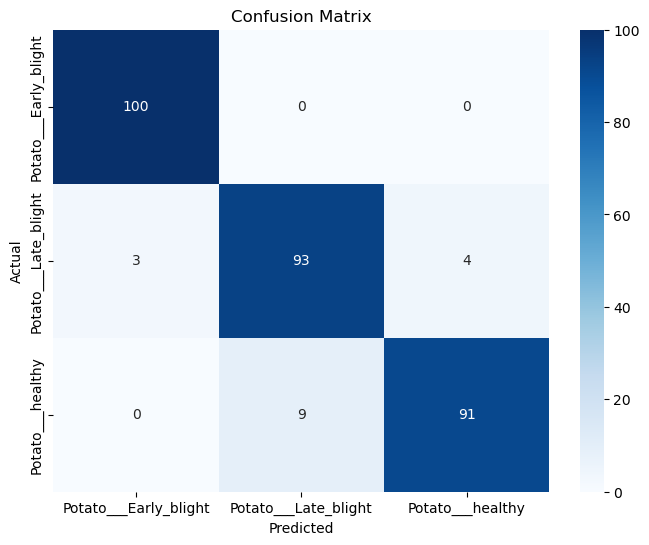

In [18]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

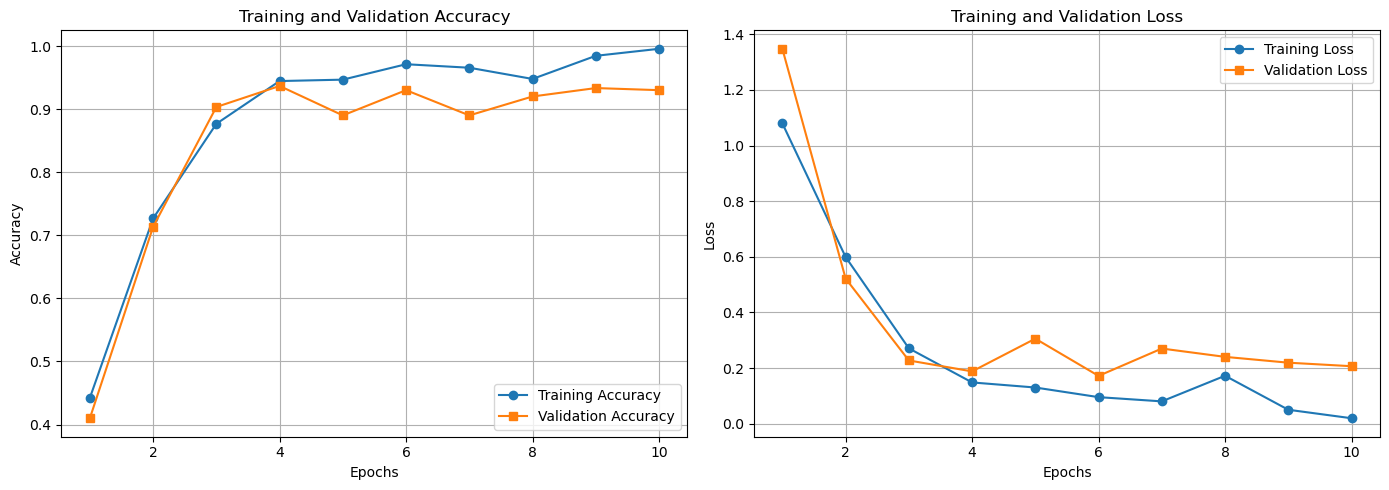

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, 11) # Hamare 10 epochs thay

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
dbdata = pd.read_csv("https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv")
dbdata.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
dbdata.shape

(768, 9)

In [23]:
cols_to_clean_db = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

dbdata[cols_to_clean_db] = dbdata[cols_to_clean_db].replace(0, np.nan)

dbdata[cols_to_clean_db] = dbdata[cols_to_clean_db].fillna(dbdata[cols_to_clean_db].median())
print(dbdata[cols_to_clean_db].isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [24]:
X_task2b = dbdata.drop('Outcome', axis=1)
y_task2b = dbdata['Outcome']

X_train_2b, X_test_2b, y_train_2b, y_test_2b = train_test_split(X_task2b, y_task2b, test_size=0.2, random_state=42)

In [25]:
scaler_2b = StandardScaler()
X_train_scaled_2b = scaler_2b.fit_transform(X_train_2b)
X_test_scaled_2b = scaler_2b.transform(X_test_2b)

**RandomForestClassifier**

In [26]:
rf_model_2b = RandomForestClassifier(random_state=42)
rf_model_2b.fit(X_train_scaled_2b, y_train_2b)

RandomForestClassifier(random_state=42)

In [29]:
rf_pred_2b = rf_model_2b.predict(X_test_scaled_2b)
rf_prob_2b = rf_model_2b.predict_proba(X_test_scaled_2b)[:, 1]

rf_accuracy = accuracy_score(y_test_2b, rf_pred_2b)
rf_precision = precision_score(y_test_2b, rf_pred_2b)
rf_recall = recall_score(y_test_2b, rf_pred_2b)
rf_f1 = f1_score(y_test_2b, rf_pred_2b)
rf_auc = roc_auc_score(y_test_2b, rf_prob_2b)

print("Random Forest Performance Metrics:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"AUC Score: {rf_auc:.4f}")

Random Forest Performance Metrics:
Accuracy:  0.7338
Precision: 0.6250
Recall:    0.6364
F1 Score:  0.6306
AUC Score: 0.8341


**XGBClassifier**

In [30]:
xgb_model_2b = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model_2b.fit(X_train_scaled_2b, y_train_2b)

C:\Users\abc\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:22:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [31]:
xgb_pred_2b = xgb_model_2b.predict(X_test_scaled_2b)
xgb_prob_2b = xgb_model_2b.predict_proba(X_test_scaled_2b)[:, 1]

xgb_accuracy = accuracy_score(y_test_2b, xgb_pred_2b)
xgb_precision = precision_score(y_test_2b, xgb_pred_2b)
xgb_recall = recall_score(y_test_2b, xgb_pred_2b)
xgb_f1 = f1_score(y_test_2b, xgb_pred_2b)
xgb_auc = roc_auc_score(y_test_2b, xgb_prob_2b)

print("XGBoost Performance Metrics:")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"AUC Score: {xgb_auc:.4f}")

XGBoost Performance Metrics:
Accuracy:  0.7143
Precision: 0.5873
Recall:    0.6727
F1 Score:  0.6271
AUC Score: 0.7774


**SVM**

In [32]:
svm_model_2b = SVC(probability=True, random_state=42)
svm_model_2b.fit(X_train_scaled_2b, y_train_2b)

SVC(probability=True, random_state=42)

In [33]:
svm_pred_2b = svm_model_2b.predict(X_test_scaled_2b)
svm_prob_2b = svm_model_2b.predict_proba(X_test_scaled_2b)[:, 1]

svm_accuracy = accuracy_score(y_test_2b, svm_pred_2b)
svm_precision = precision_score(y_test_2b, svm_pred_2b)
svm_recall = recall_score(y_test_2b, svm_pred_2b)
svm_f1 = f1_score(y_test_2b, svm_pred_2b)
svm_auc = roc_auc_score(y_test_2b, svm_prob_2b)

print("Support Vector Machine (SVM) Performance Metrics:")
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")
print(f"AUC Score: {svm_auc:.4f}")

Support Vector Machine (SVM) Performance Metrics:
Accuracy:  0.7468
Precision: 0.6667
Recall:    0.5818
F1 Score:  0.6214
AUC Score: 0.8086




<span style="font-size:30px;">IMPLEMANTAION 2</SPN>

**<span style="font-size:20px;"> REGRESSION </SPN>**

In [36]:
insdf = pd.read_csv('insurance.csv')
insdf.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [37]:
insdf.shape

(1338, 7)

In [38]:
insdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [39]:
insdf.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [40]:
cols_to_check_insdf = ['age', 'bmi', 'children', 'charges']
print("Count of Zero values in each column:\n")
for col in cols_to_check_insdf:
    zero_count = (insdf[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")

Count of Zero values in each column:

age: 0 zeros
bmi: 0 zeros
children: 574 zeros
charges: 0 zeros


In [41]:
print("Unique values in 'sex':", insdf['sex'].unique())
print("Unique values in 'smoker':", insdf['smoker'].unique())
print("Unique values in 'region':", insdf['region'].unique())
numeric_insdf = insdf.select_dtypes(include=[np.number])
print("\nCorrelation with Charges:")
print(numeric_insdf.corr()['charges'].sort_values(ascending=False))

Unique values in 'sex': ['female' 'male']
Unique values in 'smoker': ['yes' 'no']
Unique values in 'region': ['southwest' 'southeast' 'northwest' 'northeast']

Correlation with Charges:
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [42]:
# Encoding
le_ins = LabelEncoder()
insdf['sex'] = le_ins.fit_transform(insdf['sex'])
insdf['smoker'] = le_ins.fit_transform(insdf['smoker'])
#for region one-hot encoding which will create new column
insdf = pd.get_dummies(insdf, columns=['region'], drop_first=True)

In [43]:
insdf

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,True,False,False
1334,18,0,31.920,0,0,2205.98080,False,False,False
1335,18,0,36.850,0,0,1629.83350,False,True,False
1336,21,0,25.800,0,0,2007.94500,False,False,True


In [44]:
X_ins = insdf.drop('charges', axis=1)
y_ins = insdf['charges']

In [45]:
X_train_ins, X_test_ins, y_train_ins, y_test_ins = train_test_split(X_ins, y_ins, test_size=0.2, random_state=42)

In [46]:
scaler_ins = StandardScaler()
X_train_scaled_ins = scaler_ins.fit_transform(X_train_ins)
X_test_scaled_ins = scaler_ins.transform(X_test_ins)

**DNN**

In [48]:
dnn_model = Sequential([
    
    tf.keras.layers.Input(shape=(X_train_scaled_ins.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

In [49]:
dnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
dnn_model.summary()

print("Training DNN model...")
history_ins = dnn_model.fit(
    X_train_scaled_ins, y_train_ins, 
    validation_split=0.2, 
    epochs=100, 
    batch_size=32, 
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Training DNN model...
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 325441056.0000 - mae: 13517.5283 - val_loss: 310306624.0000 - val_mae: 12653.1846
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 325343968.0000 - mae: 13514.0410 - val_loss: 310154752.0000 - val_mae: 12647.5674
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 325061248.0000 - mae: 13504.2207 - val_loss: 309716192.0000 - val_mae: 12632.3789
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 324296384.0000 - mae: 13479.4092 - val_loss: 308620320.0000 - val_mae: 12596.3252
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 322470080.0000 - mae: 13423.1533 - val_loss: 306197536.0000 - val_mae: 12519.4678
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 318717312.0000 - mae: 13310.0234 - val_loss: 301442400.0000 - val_mae: 12374.0107
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 311673024.0000 - mae: 13108.2090 - val_loss: 293338816.0000 - val_mae: 1

In [50]:
y_pred_dnn = dnn_model.predict(X_test_scaled_ins)

mae_dnn = mean_absolute_error(y_test_ins, y_pred_dnn)
mse_dnn = mean_squared_error(y_test_ins, y_pred_dnn)
rmse_dnn = np.sqrt(mse_dnn)
r2_dnn = r2_score(y_test_ins, y_pred_dnn)
mape_dnn = mean_absolute_percentage_error(y_test_ins, y_pred_dnn)

print(f"DNN Regression Results:")
print(f"Mean Absolute Error (MAE): {mae_dnn:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dnn:.2f}") 
print(f"R-squared (R2) Score: {r2_dnn:.4f}")
print(f"DNN MAPE: {mape_dnn:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
DNN Regression Results:
Mean Absolute Error (MAE): 3631.87
Root Mean Squared Error (RMSE): 5301.98
R-squared (R2) Score: 0.8189
DNN MAPE: 0.4468


**Random Forest Regressor**

In [51]:
rf_regressor_ins = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor_ins.fit(X_train_scaled_ins, y_train_ins)

RandomForestRegressor(random_state=42)

In [52]:
y_pred_rf_ins = rf_regressor_ins.predict(X_test_scaled_ins)

mae_rf_ins = mean_absolute_error(y_test_ins, y_pred_rf_ins)
mse_rf_ins = mean_squared_error(y_test_ins, y_pred_rf_ins)
rmse_rf_ins = np.sqrt(mse_rf_ins)
r2_rf_ins = r2_score(y_test_ins, y_pred_rf_ins)
mape_rf_ins = mean_absolute_percentage_error(y_test_ins, y_pred_rf_ins)

print(f"Random Forest Regression Results:")
print(f"Mean Absolute Error (MAE): {mae_rf_ins:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_ins:.2f}")
print(f"R-squared (R2) Score: {r2_rf_ins:.4f}")
print(f"Random Forest MAPE: {mape_rf_ins:.4f}")

Random Forest Regression Results:
Mean Absolute Error (MAE): 2544.98
Root Mean Squared Error (RMSE): 4569.15
R-squared (R2) Score: 0.8655
Random Forest MAPE: 0.3231


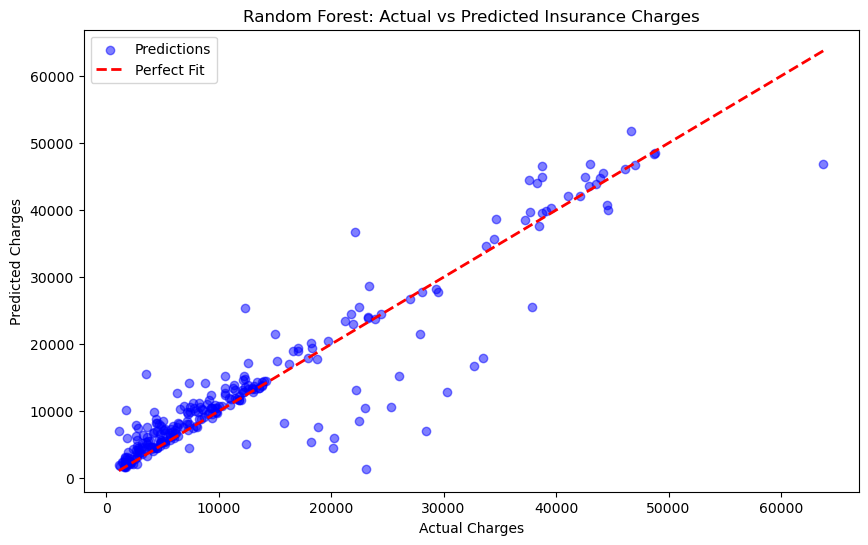

In [53]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_ins, y_pred_rf_ins, alpha=0.5, color='blue', label='Predictions')
plt.plot([y_test_ins.min(), y_test_ins.max()], [y_test_ins.min(), y_test_ins.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Random Forest: Actual vs Predicted Insurance Charges')
plt.legend()
plt.show()





<span style="font-size:30px;"> IMPLEMANTAION 3 </SPN>

In [54]:
df_stk=pd.read_csv('healthcare-dataset-stroke-data.csv')
df_stk

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [56]:
df_stk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [57]:
df_stk.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [60]:
#we will consider the data of only participants who are over 18 years old
df_stk = df_stk[df_stk['age'] > 18].copy()
df_stk.shape 

(4194, 12)

In [61]:
print("Missing Values per column\n: ", df_stk.isnull().sum())

df_stk.info()

Missing Values per column
:  id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  180
smoking_status         0
stroke                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 4194 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4194 non-null   int64  
 1   gender             4194 non-null   object 
 2   age                4194 non-null   float64
 3   hypertension       4194 non-null   int64  
 4   heart_disease      4194 non-null   int64  
 5   ever_married       4194 non-null   object 
 6   work_type          4194 non-null   object 
 7   Residence_type     4194 non-null   object 
 8   avg_glucose_level  4194 non-null   float64
 9   bmi                4014

In [62]:
df_stk.drop('id', axis=1, inplace=True) 
df_stk.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [63]:
df_stk['stroke'].value_counts()

stroke
0    3947
1     247
Name: count, dtype: int64

In [64]:
df_stk['bmi'] = df_stk['bmi'].fillna(df_stk['bmi'].median())
print("BMI Nulls after:", df_stk['bmi'].isnull().sum())

BMI Nulls after: 0


In [65]:
df_stk['gender'] = df_stk['gender'].replace('Other', 'Male')
print("Gender column cleaned.")

Gender column cleaned.


In [66]:
le_stk = LabelEncoder()
categorical_columns_stk = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in ['gender', 'ever_married', 'Residence_type']:
    df_stk[col] = le_stk.fit_transform(df_stk[col])


df_stk = pd.get_dummies(df_stk, columns=['work_type','smoking_status'], drop_first=True)

df_stk.shape

(4194, 15)

In [67]:
X_stk = df_stk.drop('stroke', axis=1)
y_stk = df_stk['stroke']

X_train_stk, X_test_stk, y_train_stk, y_test_stk = train_test_split(X_stk, y_stk, test_size=0.2, random_state=42)

In [68]:
scaler_stk = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']
X_train_stk[num_cols] = scaler_stk.fit_transform(X_train_stk[num_cols])
X_test_stk[num_cols] = scaler_stk.transform(X_test_stk[num_cols])


In [69]:
#SMOTE to handle data imbalance 
smote_stk = SMOTE(random_state=42)
X_train_stk_res, y_train_stk_res = smote_stk.fit_resample(X_train_stk, y_train_stk)
print("SMOTE successfully applied")
print("Balanced Training shape:", X_train_stk.shape)


SMOTE successfully applied
Balanced Training shape: (3355, 14)


In [70]:
print("New Balanced Data (X_train_stk_res):", X_train_stk_res.shape)

New Balanced Data (X_train_stk_res): (6348, 14)


In [71]:
lr_model_stk = LogisticRegression(random_state=42, max_iter=1000)
print("Training Logistic Regression...")
lr_model_stk.fit(X_train_stk_res, y_train_stk_res)

Training Logistic Regression...


LogisticRegression(max_iter=1000, random_state=42)

In [72]:
y_pred_lr_stk = lr_model_stk.predict(X_test_stk)
y_prob_lr_stk = lr_model_stk.predict_proba(X_test_stk)[:, 1]
print("\nLogistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test_stk, y_pred_lr_stk):.4f}")
print(f"Precision: {precision_score(y_test_stk, y_pred_lr_stk):.4f}")
print(f"Recall:    {recall_score(y_test_stk, y_pred_lr_stk):.4f} ")
print(f"F1-Score:  {f1_score(y_test_stk, y_pred_lr_stk):.4f}")
print(f"AUC Score: {roc_auc_score(y_test_stk, y_prob_lr_stk):.4f}")


Logistic Regression Results:
Accuracy:  0.7533
Precision: 0.2000
Recall:    0.7121 
F1-Score:  0.3123
AUC Score: 0.8019


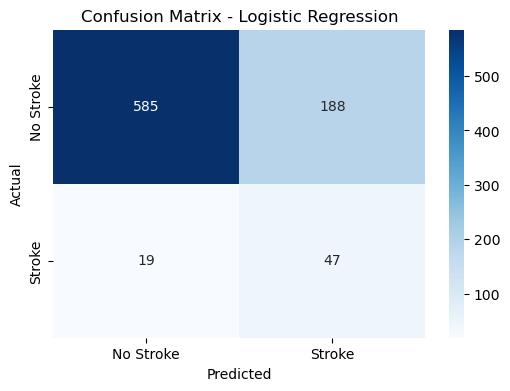

In [78]:
plt.figure(figsize=(6, 4))
cm_lr_stk = confusion_matrix(y_test_stk, y_pred_lr_stk)
sns.heatmap(cm_lr_stk, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [74]:
from sklearn.metrics import roc_curve

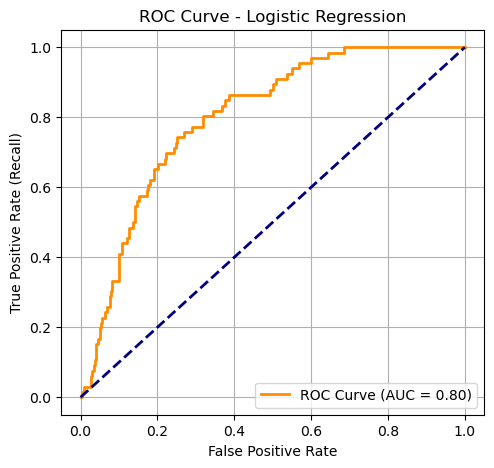

In [75]:
fpr, tpr, thresholds = roc_curve(y_test_stk, y_prob_lr_stk)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {0.80:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)

**RANDOMFOREST** 

In [76]:
rf_model_stk = RandomForestClassifier(n_estimators=100, random_state=42)
print("Training Random Forest... ")
rf_model_stk.fit(X_train_stk_res, y_train_stk_res)

Training Random Forest... 


RandomForestClassifier(random_state=42)

In [77]:
y_pred_rf_stk = rf_model_stk.predict(X_test_stk)
y_prob_rf_stk = rf_model_stk.predict_proba(X_test_stk)[:, 1]
print("\nRandom Forest Results:")
print(f"Accuracy:  {accuracy_score(y_test_stk, y_pred_rf_stk):.4f}")
print(f"Precision: {precision_score(y_test_stk, y_pred_rf_stk):.4f}")
print(f"Recall:    {recall_score(y_test_stk, y_pred_rf_stk):.4f}")
print(f"F1-Score:  {f1_score(y_test_stk, y_pred_rf_stk):.4f}")
print(f"AUC Score: {roc_auc_score(y_test_stk, y_prob_rf_stk):.4f}")



Random Forest Results:
Accuracy:  0.8582
Precision: 0.1646
Recall:    0.1970
F1-Score:  0.1793
AUC Score: 0.7480


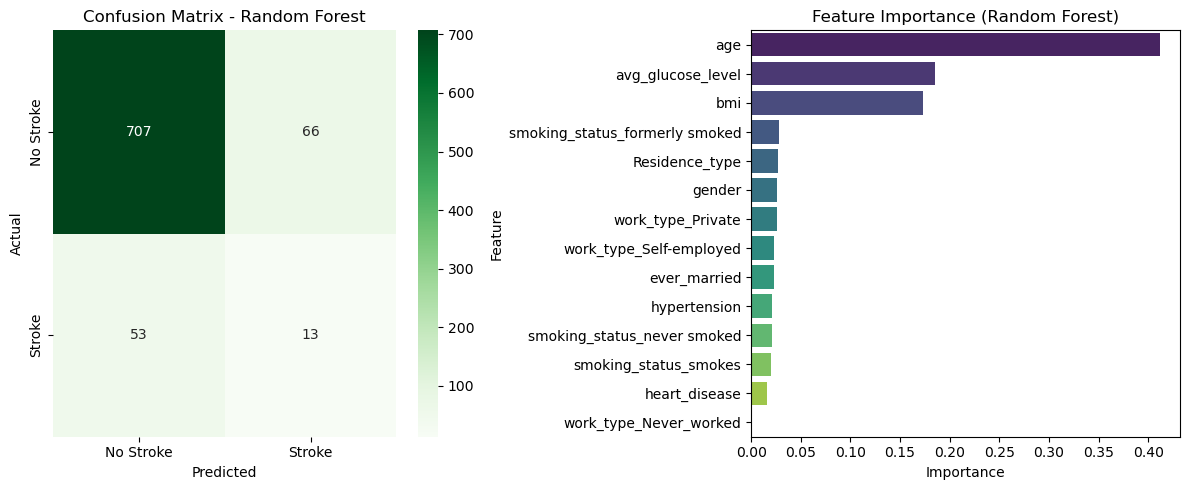

In [83]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_rf_stk = confusion_matrix(y_test_stk, y_pred_rf_stk)
sns.heatmap(cm_rf_stk, annot=True, fmt='d', cmap='Greens', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 2, 2)
importances = rf_model_stk.feature_importances_
feature_names_rf_stk = X_stk.columns
rf_importance_stk = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importance_stk = rf_importance_stk.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', hue='Feature', data=rf_importance_stk, palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

**Decision Tree**

In [81]:
dt_model_stk = DecisionTreeClassifier(random_state=42)
print("Training Decision Tree.....")
dt_model_stk.fit(X_train_stk_res, y_train_stk_res)

Training Decision Tree.....


DecisionTreeClassifier(random_state=42)

In [82]:
y_pred_dt_stk = dt_model_stk.predict(X_test_stk)
y_prob_dt_stk = dt_model_stk.predict_proba(X_test_stk)[:, 1]

print("\nDecision Tree Results:")
print(f"Accuracy:  {accuracy_score(y_test_stk, y_pred_dt_stk):.4f}")
print(f"Precision: {precision_score(y_test_stk, y_pred_dt_stk):.4f}")
print(f"Recall:    {recall_score(y_test_stk, y_pred_dt_stk):.4f}")
print(f"F1-Score:  {f1_score(y_test_stk, y_pred_dt_stk):.4f}")
print(f"AUC Score: {roc_auc_score(y_test_stk, y_prob_dt_stk):.4f}")


Decision Tree Results:
Accuracy:  0.8319
Precision: 0.1212
Recall:    0.1818
F1-Score:  0.1455
AUC Score: 0.5346


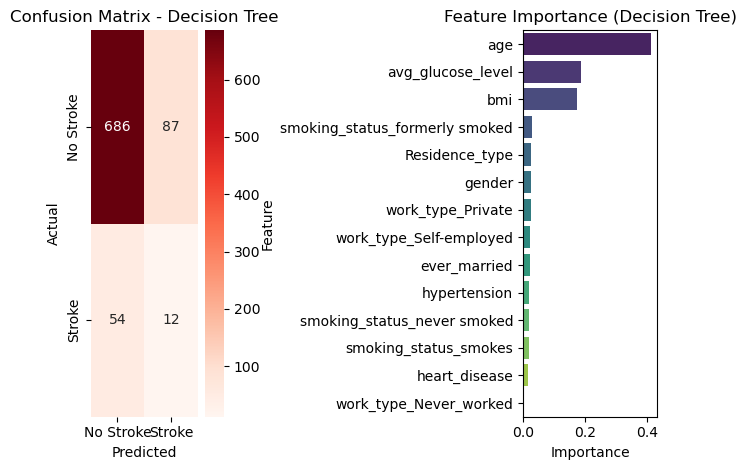

In [86]:
plt.subplot(1, 2, 1)
cm_dt_stk = confusion_matrix(y_test_stk, y_pred_dt_stk)
sns.heatmap(cm_dt_stk, annot=True, fmt='d', cmap='Reds', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.subplot(1, 2, 2)

importances_dt_stk = dt_model_stk.feature_importances_
feature_names_dt_stk = X_stk.columns
dt_importance_stk = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
dt_importance_stk = dt_importance_stk.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', hue='Feature', data=dt_importance_stk, palette='viridis', legend=False)
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

**KNeighborsClassifier**

In [87]:
from sklearn.neighbors import KNeighborsClassifier

In [90]:
knn_model = KNeighborsClassifier(n_neighbors=5)
print("Training KNN... ")
knn_model.fit(X_train_stk_res, y_train_stk_res)

Training KNN... 


KNeighborsClassifier()

In [91]:
y_pred_knn = knn_model.predict(X_test_stk)
y_prob_knn = knn_model.predict_proba(X_test_stk)[:, 1]

print("\nKNN Results:")
print(f"Accuracy:  {accuracy_score(y_test_stk, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test_stk, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test_stk, y_pred_knn):.4f}")
print(f"F1-Score:  {f1_score(y_test_stk, y_pred_knn):.4f}")
print(f"AUC Score: {roc_auc_score(y_test_stk, y_prob_knn):.4f}")


KNN Results:
Accuracy:  0.7390
Precision: 0.1156
Recall:    0.3485
F1-Score:  0.1736
AUC Score: 0.6404


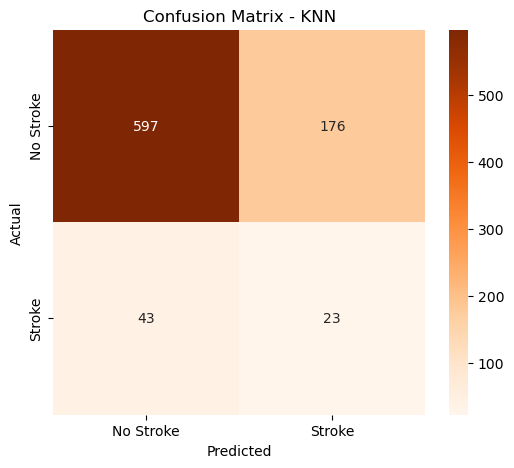

In [92]:
plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test_stk, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()